# Does superspheroidal shape reduce the contrast needed for $\gamma>3$?

**Question.** The DV-partnering requirement $\gamma = \varepsilon_z/\varepsilon_t > 3$ demands a constituent contrast $r = \varepsilon_a/\varepsilon_b$ exceeding a shape-dependent threshold $r^*$. The previous notebook fixed one aspect ratio ($c/a=5$) and hinted that superspheroids beat spheroids ($r^*: 29.4 \to \approx 25$). Here we map $r^*(c/a)$ for the whole ladder of shapes between spheroid and cylinder/cuboid, to quantify **how much contrast the superspheroidal deformation saves relative to the ordinary spheroid Bruggeman model** — and where the saving matters.

**Protocol.** All particles share the same equatorial radius $a=1$ and the same bounding aspect ratio $c/a$; lossless constituents; identically oriented; Bruggeman formalism throughout (Maxwell Garnett is disqualified in this regime by its screening pole). Families compared, from smooth to squared:
- **spheroid** $(m,n)=(1,1)$ — the baseline "normal Bruggeman" model;
- **type (i)** $(2,2)$ and its limit, the **square prism** (cuboid);
- **type (ii)** $(1,2)$, $(1,4)$ and their limit, the **cylinder**.

$r^*$ is found by bisection on $\max_{f_\mathcal{A}}\gamma(r) = 3$. (Comparison is at equal bounding box, the natural fabrication constraint; a squared particle contains more material per particle than its inscribed spheroid — that extra polarizable volume near the ends is precisely the mechanism at work.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
plt.rcParams['figure.dpi'] = 110

def _quad01(N):
    xg, wg = np.polynomial.legendre.leggauss(N)
    v = 0.5*(xg + 1.0)
    return np.sin(0.5*np.pi*v)**2, 0.5*wg*0.5*np.pi*np.sin(np.pi*v)

def Lt_superspheroid(gamma, c, m, n, a=1.0, N=48):
    gamma = np.atleast_1d(np.asarray(gamma, dtype=complex))
    t, w = _quad01(N)
    S, T = np.meshgrid(t, t, indexing='ij')
    W = np.outer(w, w).ravel(); s, tau = S.ravel(), T.ravel()
    A = 1 - tau**(2*n); B = 1 - s**(2*m)
    x = a*A**(1/(2*m))*B**(1/(2*m)); y = a*A**(1/(2*m))*s; z = c*tau
    F = a*a*c*A**(1/m)*B**(1/(2*m))
    R3 = (gamma[:, None]*(x*x + y*y)[None, :] + (z*z)[None, :])**1.5
    return (2.0/np.pi)*np.sum(W[None, :]*F[None, :]/R3, axis=1)

def Lt_cylinder(gamma, c, a=1.0):
    g = np.asarray(gamma, dtype=complex); return c/(2*g*np.sqrt(a*a*g + c*c))

def Lt_cuboid(gamma, c, a=1.0):
    g = np.asarray(gamma, dtype=complex); rg = np.sqrt(g)
    return 2/(np.pi*g)*(np.arctan(a*rg/c) + np.arctan((-2*a*rg + np.sqrt(2*a*a*g + c*c))/c))

def Lt_of(shape, gamma, c):
    if shape == 'cyl_inf':  return 1/(2*np.asarray(gamma, complex))
    if shape == 'cylinder': return Lt_cylinder(gamma, c)
    if shape == 'cuboid':   return Lt_cuboid(gamma, c)
    m, n = shape;           return Lt_superspheroid(gamma, c, m, n)

def bruggeman_fast(fA, c, shape, ea, eb=1.0, tol=1e-10, maxit=160, init=None):
    """Bruggeman with per-axis exact quadratic solve at frozen N (physical branch is
    the root continuous with eps -> <eps> as N -> 0)."""
    fA = np.asarray(fA, float)
    avg = fA*ea + (1-fA)*eb
    et, ez = ((avg.astype(complex), avg.astype(complex)) if init is None
              else (init[0].copy(), init[1].copy()))
    for it in range(maxit):
        g = ez/et; Lt = Lt_of(shape, g, c)
        new = []
        for N in (g*Lt/et, (1 - 2*g*Lt)/ez):
            b = 1 + N*(ea + eb); q = avg + N*ea*eb
            new.append(2*q/(b + np.sqrt(b*b - 4*N*q)))   # stable form of the '-' root
        err = max(np.max(np.abs(new[0]-et)), np.max(np.abs(new[1]-ez)))
        et, ez = new
        if err < tol: break
    return et.real, ez.real, it+1

fgrid = np.linspace(0.02, 0.98, 49)
_warm = {}
def gamma_max(r, shape, c):
    key = (str(shape), c)
    et, ez, _ = bruggeman_fast(fgrid, c, shape, r,
                               init=tuple(x.astype(complex) for x in _warm[key]) if key in _warm else None)
    _warm[key] = (et, ez)
    g = ez/et; k = int(np.argmax(g))
    return g[k], fgrid[k]

def threshold(shape, c, lo=5.0, hi=4000.0, nbis=14, target=3.0):
    if gamma_max(hi, shape, c)[0] < target: return np.inf
    if gamma_max(lo, shape, c)[0] >= target: lo = lo/3
    for _ in range(nbis):
        mid = np.sqrt(lo*hi)
        lo, hi = (mid, hi) if gamma_max(mid, shape, c)[0] < target else (lo, mid)
    return float(np.sqrt(lo*hi))

In [2]:
print('validation against the previous (damped fixed-point) solver:')
for shape, c, ref in (('cylinder', 10.0, 18.86), ((1, 2), 5.0, 25.20),
                      ((1, 1), 5.0, 29.43), ((2, 2), 5.0, 24.94)):
    rs = threshold(shape, c, lo=ref*0.5, hi=ref*2.2, nbis=11)
    print(f'  {str(shape):10s} c/a={c:4.1f}: r* = {rs:6.2f}   (reference {ref})')
ea = 30.0
et, ez, _ = bruggeman_fast(fgrid, 5.0, (1, 2), ea)
g = ez/et; Lt = Lt_of((1, 2), g, 5.0).real
Nt, Nz = g*Lt/et, (1 - 2*g*Lt)/ez
res = max(np.max(np.abs(fgrid*(ea-et)/(1+Nt*(ea-et)) + (1-fgrid)*(1-et)/(1+Nt*(1-et)))),
          np.max(np.abs(fgrid*(ea-ez)/(1+Nz*(ea-ez)) + (1-fgrid)*(1-ez)/(1+Nz*(1-ez)))))
print(f'Eq.(14) residual certificate, (1,2), c=5, r=30: {res:.1e}')

validation against the previous (damped fixed-point) solver:
  cylinder   c/a=10.0: r* =  18.85   (reference 18.86)


  (1, 2)     c/a= 5.0: r* =  25.21   (reference 25.2)


  (1, 1)     c/a= 5.0: r* =  29.42   (reference 29.43)


  (2, 2)     c/a= 5.0: r* =  24.95   (reference 24.94)


Eq.(14) residual certificate, (1,2), c=5, r=30: 5.6e-11


In [3]:
FAMILIES = [((1, 1),    'spheroid (1,1)',      'tab:purple'),
            ((2, 2),    'type (i) (2,2)',      'tab:green'),
            ('cuboid',  'square prism',        'olive'),
            ((1, 2),    'type (ii) (1,2)',     'tab:blue'),
            ((1, 4),    'type (ii) (1,4)',     'tab:cyan'),
            ('cylinder','cylinder',            'tab:orange')]
CGRID = np.array([20.0, 12.0, 8.0, 5.0, 3.0, 2.0, 1.5])     # descending: adaptive brackets

RECOMPUTE = False   # set True to regenerate the table below with the loop that produced it (~4 min)
if RECOMPUTE:
    t0 = time.perf_counter()
    RSTAR = {}
    for shape, name, _ in FAMILIES:
        lo, hi = 5.0, 4000.0
        vals = []
        for c in CGRID:
            rs = threshold(shape, c, lo, hi)
            vals.append(rs)
            if np.isfinite(rs): lo, hi = rs*0.98, rs*8.0
        RSTAR[name] = np.array(vals)
    print(f'sweep time: {time.perf_counter()-t0:.0f} s')
else:   # cached output of the RECOMPUTE branch (fgrid of 49 points, 14 bisections)
    RSTAR = {
    'spheroid (1,1)': np.array([18.96, 20.32, 22.70, 29.42, 59.34, 471.30, np.inf]),
    'type (i) (2,2)': np.array([18.35, 19.06, 20.48, 24.94, 45.73, 325.73, np.inf]),
    'square prism': np.array([18.23, 18.75, 19.82, 23.33, 40.34, 268.39, np.inf]),
    'type (ii) (1,2)': np.array([18.38, 19.13, 20.62, 25.20, 45.56, 256.27, np.inf]),
    'type (ii) (1,4)': np.array([18.24, 18.78, 19.88, 23.36, 38.79, 167.80, np.inf]),
    'cylinder': np.array([18.17, 18.57, 19.40, 22.02, 33.26, 107.17, np.inf]),
    }

hdr = 'c/a     ' + ''.join(f'{n:>18s}' for _, n, _ in FAMILIES)
print(hdr)
for j, c in enumerate(CGRID):
    row = f'{c:4.1f}    '
    for _, n, _ in FAMILIES:
        v = RSTAR[n][j]
        row += f'{v:18.2f}' if np.isfinite(v) else f'{"unreachable":>18s}'
    print(row)

c/a         spheroid (1,1)    type (i) (2,2)      square prism   type (ii) (1,2)   type (ii) (1,4)          cylinder
20.0                 18.96             18.35             18.23             18.38             18.24             18.17
12.0                 20.32             19.06             18.75             19.13             18.78             18.57
 8.0                 22.70             20.48             19.82             20.62             19.88             19.40
 5.0                 29.42             24.94             23.33             25.20             23.36             22.02
 3.0                 59.34             45.73             40.34             45.56             38.79             33.26
 2.0                471.30            325.73            268.39            256.27            167.80            107.17
 1.5           unreachable       unreachable       unreachable       unreachable       unreachable       unreachable


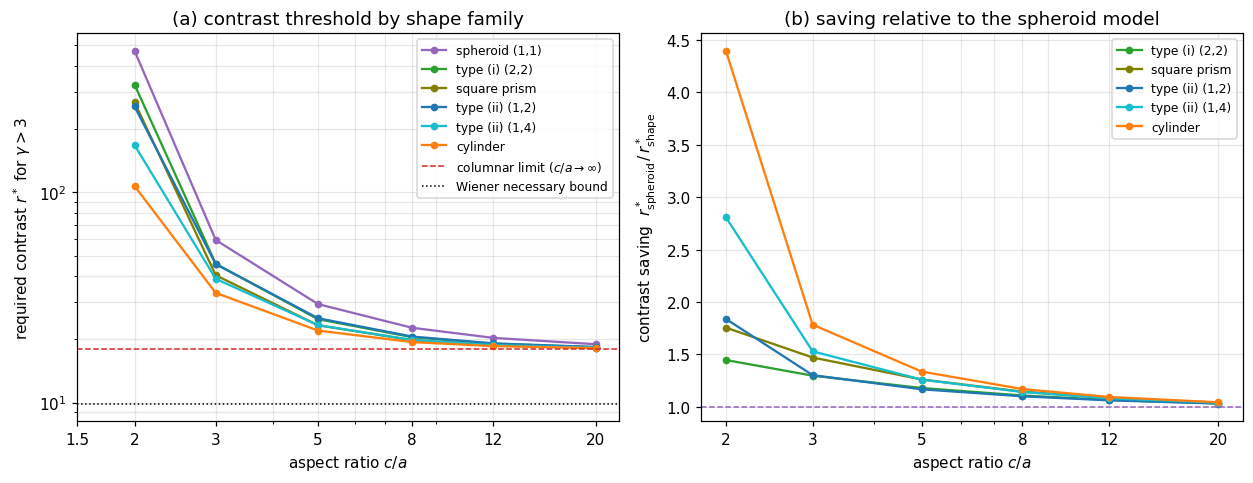

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.5))
mask = np.isfinite(RSTAR['spheroid (1,1)'])
for shape, name, col in FAMILIES:
    m = np.isfinite(RSTAR[name])
    a1.plot(CGRID[m], RSTAR[name][m], 'o-', ms=4, color=col, label=name)
a1.axhline(17.95, color='tab:red', ls='--', lw=1, label=r'columnar limit ($c/a\to\infty$)')
a1.axhline(5 + 2*np.sqrt(6), color='k', ls=':', lw=1, label='Wiener necessary bound')
a1.set_xscale('log'); a1.set_yscale('log')
a1.set_xlabel('aspect ratio $c/a$'); a1.set_ylabel(r'required contrast $r^*$ for $\gamma>3$')
a1.set_title('(a) contrast threshold by shape family')
a1.set_xticks([1.5, 2, 3, 5, 8, 12, 20]); a1.set_xticklabels(['1.5', '2', '3', '5', '8', '12', '20'])
a1.legend(fontsize=8); a1.grid(alpha=0.3, which='both')

base = RSTAR['spheroid (1,1)']
for shape, name, col in FAMILIES[1:]:
    m = np.isfinite(base) & np.isfinite(RSTAR[name])
    a2.plot(CGRID[m], base[m]/RSTAR[name][m], 'o-', ms=4, color=col, label=name)
a2.axhline(1, color='tab:purple', lw=1, ls='--')
a2.set_xscale('log')
a2.set_xlabel('aspect ratio $c/a$'); a2.set_ylabel(r'contrast saving  $r^*_{\rm spheroid}\,/\,r^*_{\rm shape}$')
a2.set_title('(b) saving relative to the spheroid model')
a2.set_xticks([2, 3, 5, 8, 12, 20]); a2.set_xticklabels(['2', '3', '5', '8', '12', '20'])
a2.legend(fontsize=8); a2.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

## The geometric wall: a minimum aspect ratio no contrast can buy through

As $r\to\infty$, $\gamma_{\max}$ saturates at a finite, shape-dependent value: past a point, more contrast stops helping (the transverse response of near-percolating high-index columns grows in lock-step with the axial one). If the saturation value is below 3, the shape can **never** partner a lossless DV wave, at any contrast. We locate the wall using $r=3\times10^4$ as a proxy for $r\to\infty$.

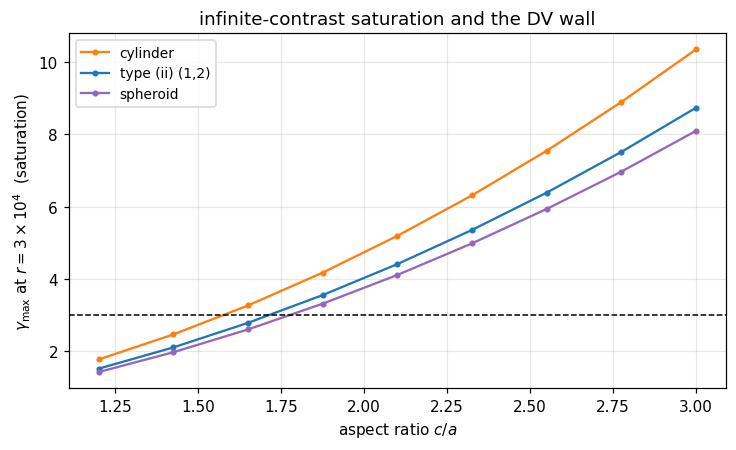

minimum viable aspect ratio, cylinder        : c/a = 1.58


minimum viable aspect ratio, type (ii) (1,2) : c/a = 1.72


minimum viable aspect ratio, spheroid        : c/a = 1.78


In [5]:
def wall(shape, lo, hi, r=3e4, nbis=11):
    for _ in range(nbis):
        mid = 0.5*(lo + hi)
        lo, hi = (mid, hi) if gamma_max(r, shape, mid)[0] < 3 else (lo, mid)
    return 0.5*(lo + hi)

cw = np.linspace(1.2, 3.0, 9)
PROG = open('progress.txt', 'a')
fig, ax = plt.subplots(figsize=(6.8, 4.2))
for shape, name, col in (( 'cylinder', 'cylinder', 'tab:orange'),
                         ((1, 2), 'type (ii) (1,2)', 'tab:blue'),
                         ((1, 1), 'spheroid', 'tab:purple')):
    gs = [gamma_max(3e4, shape, c)[0] for c in cw]
    print(f'wall curve {name} done', file=PROG, flush=True)
    ax.plot(cw, gs, 'o-', ms=3, color=col, label=name)
ax.axhline(3, color='k', ls='--', lw=1)
ax.set_xlabel('aspect ratio $c/a$'); ax.set_ylabel(r'$\gamma_{\max}$ at $r=3\times10^4$  (saturation)')
ax.set_title('infinite-contrast saturation and the DV wall')
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

for shape, name in (('cylinder', 'cylinder'), ((1, 2), 'type (ii) (1,2)'), ((1, 1), 'spheroid')):
    print(f'minimum viable aspect ratio, {name:16s}: c/a = {wall(shape, 1.3, 2.4):.2f}')

In [6]:
# effective aspect ratio: the spheroid c/a that matches each shape's r*
logc, logr = np.log(CGRID[::-1]), np.log(RSTAR['spheroid (1,1)'][::-1])
m = np.isfinite(logr); logc, logr = logc[m], logr[m]
print('a squared particle performs like a LONGER spheroid:')
print('c/a of shape -> equivalent spheroid c/a')
for shape, name, _ in FAMILIES[1:]:
    line = f'  {name:16s}: '
    for j, c in enumerate(CGRID):
        v = RSTAR[name][j]
        if np.isfinite(v) and logr.min() <= np.log(v) <= logr.max():
            ceff = np.exp(np.interp(np.log(v), logr[::-1], logc[::-1]))
            line += f'{c:g} -> {ceff:.1f}   '
    print(line)
print()
print('required pillar height at fixed materials (r = 25):')
for shape, name, _ in FAMILIES:
    rr = RSTAR[name]; m2 = np.isfinite(rr)
    lr, lc = np.log(rr[m2]), np.log(CGRID[m2])      # CGRID descending -> lr increasing
    if lr.min() <= np.log(25) <= lr.max():
        cneed = np.exp(np.interp(np.log(25), lr, lc))
        print(f'  {name:16s}: c/a >= {cneed:.2f}')

a squared particle performs like a LONGER spheroid:
c/a of shape -> equivalent spheroid c/a
  type (i) (2,2)  : 12 -> 19.2   8 -> 11.7   5 -> 6.7   3 -> 3.6   2 -> 2.1   
  square prism    : 8 -> 14.4   5 -> 7.6   3 -> 4.0   2 -> 2.2   
  type (ii) (1,2) : 12 -> 18.7   8 -> 11.4   5 -> 6.6   3 -> 3.6   2 -> 2.3   
  type (ii) (1,4) : 8 -> 14.1   5 -> 7.6   3 -> 4.1   2 -> 2.4   
  cylinder        : 8 -> 16.9   5 -> 8.9   3 -> 4.6   2 -> 2.7   

required pillar height at fixed materials (r = 25):
  spheroid (1,1)  : c/a >= 6.72
  type (i) (2,2)  : c/a >= 4.99
  square prism    : c/a >= 4.69
  type (ii) (1,2) : c/a >= 5.09
  type (ii) (1,4) : c/a >= 4.67
  cylinder        : c/a >= 4.27


## Conclusions

**Yes — the superspheroidal deformation genuinely reduces the required contrast, and the benefit concentrates exactly where it is most valuable: at modest, fabrication-friendly aspect ratios.** Relative to the ordinary spheroid Bruggeman model at the same bounding box, the saving in $r^*$ is only $\sim3\%$ at $c/a=20$ (all prolate shapes converge to the columnar limit $r^*\to17.95$), but grows to $14$–$21\%$ at $c/a=5$, $23$–$35\%$ at $c/a=3$, and a factor of $1.8\times$–$2.8\times$ at $c/a=2$ (spheroid $r^*=471$ vs $256$ for $(1,2)$, $168$ for $(1,4)$, $107$ for the cylinder). Equivalently, a $(1,2)$ barrel behaves like a spheroid $\sim20\%$ longer, and a cylinder like one $\sim50\%$ longer, at $c/a=3$.

**The deformation direction matters.** At low aspect ratio, squaring the *axial profile* (type (ii): $(1,2)\to(1,4)\to$ cylinder, keeping a circular cross-section) clearly beats squaring the *cross-section* (type (i): $(2,2)\to$ square prism): at $c/a=2$, the $(1,4)$ barrel needs $r^*=168$ while the square prism needs $268$. Flat end-caps extend the effective column and suppress $L_z$ (boosting $\varepsilon_z$ toward the arithmetic mean), whereas square cross-section corners add transverse polarizability that raises $\varepsilon_t$ — helping the denominator of $\gamma$, i.e. hurting. **The practical recommendation for the DV pipeline is therefore the type (ii) family with $n$ as large as fabrication allows.**

**Superspheroiding also relaxes the fundamental geometric wall.** $\gamma_{\max}$ saturates at infinite contrast, defining a minimum viable aspect ratio: $c/a \approx 1.78$ (spheroid) $\to 1.72$ ($(1,2)$) $\to 1.58$ (cylinder), computed at the $r=3\times10^4$ proxy (pushing $r$ higher shifts these by $\lesssim0.02$). Below that, no material pair can reach $\gamma=3$; just above it, thresholds are astronomically sensitive to shape — which is why the largest superspheroid dividends appear at $c/a\approx2$.

**Caveats.** Comparison is at equal bounding box (equal $a$, $c$); part of the superspheroid advantage is the extra polarizable volume near the poles, which is physically the point but means an equal-volume comparison would attribute the gain differently. All results are lossless-Bruggeman; the Maxwell Garnett route is unavailable at these contrasts (screening pole below the optimal $f_\mathcal{A}\approx0.28$), and dissipation would shift the DV criterion itself.